# Relic abundance calculations for Dark Photon DM

In [23]:
# Library imports and params
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import interpolate
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
import glob
import csv

## Defining the fonts before plotting:

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "monospace",  # Use monospace font
    "text.latex.preamble": r"\usepackage{courier}"  # Use Courier font
})
mpl.rcParams.update(mpl.rcParamsDefault)

plt.rcParams.update({
    'font.family': 'monospace',  # monospace font
    "text.latex.preamble": r"\usepackage{courier}",
    'font.size': 20,
    'axes.titlesize': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 20,
    'figure.titlesize': 20,
})

## Scalar DM case

### Annihilation cross section

First, we consider the annihilation cross section for $\sigma_{\chi \chi \rightarrow f \bar{f}}$. We find after some Feynamnn diagrams and phase space integration that:

$$
\sigma v_{\text{rel}} = \frac{8 \pi}{3} \frac{\epsilon^2 \alpha \alpha_D m^2_\chi}{\left( m_{A'}^2 - 4 m_\chi^2  \right)^2} v^2_{\text{rel}} \sum_f K_f,
$$

where the $K_f$ kinematic factor for the fermion $f$ is defined as:
$$
K_f = Q_f^2 N_c^f \sqrt{1 - \frac{m_f^2}{m_\chi^2}} \left( 1 + \frac{1}{6} \frac{m_f^2}{m_\chi^2} \right) \Theta \left( m_\chi - m_f \right).
$$

Thermally averaging using the fact that $\left\langle v^2_{\text{rel}} \right\rangle = \frac{6}{x}$, we get:

$$
\left\langle \sigma v_{\text{rel}} \right\rangle = \frac{16 \pi}{x} \frac{\epsilon^2 \alpha \alpha_D m^2_\chi}{\left( m_{A'}^2 - 4 m_\chi^2  \right)^2}  \sum_f K_f.
$$

To treat the respective kinematic factors, we must take into account that for quarks, hadrons will be the relevant decay products at low energies. Thus, we will use the $R$ ratio as proxy for decays into hadrons:

$$
R(\sqrt{s}) = \frac{\sigma \left(e^+ e^- \rightarrow \text{hadrons} \right)}{\sigma \left(e^+ e^- \rightarrow \mu^+ \mu^- \right)},
$$

so the sum over kinematic factors becomes:

$$

\sum_f K_f \sim \sum_l K_l (m_\chi) + R(2 m_\chi) K_\mu(m_\chi).

$$

First we implement this cross section. The R ratio is taken from the PDG 2020 data set and interpolated linearly. 

In [24]:
mleptons = np.array([5.11e-4, 0.106, 1.777])  # Masses of leptons in GeV

def Kl(mchi, ml):
    """Phase-space factor for chi chi -> l+ l-, zero below threshold.

    The sqrt and the 1/mchi**2 are only evaluated where mchi > ml, so closed
    channels contribute an exact 0 instead of a nan.
    """
    mchi = np.asarray(mchi, dtype=float)
    opench = mchi > ml
    r2 = np.where(opench, ml**2/np.where(opench, mchi, 1.0)**2, 0.0)
    return np.where(opench, np.sqrt(1 - r2)*(1 + r2/6), 0.0)

def sumKl(mchi):
    total = np.zeros_like(np.asarray(mchi, dtype=float))
    for ml in mleptons:
        total = total + Kl(mchi, ml)
    return total

def Kmu(mchi):
    """Muon phase-space factor, deliberately WITHOUT a threshold cut.

    This is not an open channel in its own right: it is the mu+mu-
    normalisation of the R-ratio, so it must stay un-cut. The kinematic
    condition belongs to R (see RKmu).
    """
    mchi = np.asarray(mchi, dtype=float)
    r2 = mleptons[1]**2/mchi**2
    return np.sqrt(1 - r2)*(1 + r2/6)

### Hadronic R ratio, R = sigma(e+e- -> hadrons)/sigma(e+e- -> mu+mu-),
### from the PDG compilation in data/rratio.dat (1400 points, 0.3-188.7 GeV).

def read_rratio(path="data/rratio.dat"):
    """Read the PDG R-ratio table -> (E_cm, R, dR).

    Fixed-width, per the FORTRAN format documented at the foot of the file
    (f10.5,2x,f10.5,1x,f10.5,2x,f10.5,2x,sp,f10.5,1x,f10.5,...): E(cm) at
    [0:10], R at [35:45], +stat at [47:57], -stat at [58:68].

    Lines whose E(cm) field is blank carry extra systematics for the
    preceding point rather than a new point, and are skipped. They must be
    read by column, not by str.split(): their first non-blank token is a
    signed systematic like '+5.10', which splitting would happily mistake
    for an energy.
    """
    E, R, dR = [], [], []
    with open(path) as f:
        for line in f:
            if line.startswith("*") or not line.strip():
                continue
            try:
                ecm = float(line[0:10])
            except ValueError:
                continue                                  # continuation line
            if ecm <= 0.0:
                continue
            E.append(ecm)
            R.append(float(line[35:45]))
            dR.append(0.5*(abs(float(line[47:57])) + abs(float(line[58:68]))))
    return np.array(E), np.array(R), np.array(dR)

ecm_rratio, Rdata, dRdata = read_rratio()

# 70 energies are quoted by more than one experiment, but interp1d needs a
# strictly increasing x, so repeats are collapsed into a single
# inverse-variance weighted mean (the stat errors are all non-zero).
weights_R = 1.0/dRdata**2
ecm_R, index_R = np.unique(ecm_rratio, return_inverse=True)
R_R = (np.bincount(index_R, weights=weights_R*Rdata)
       / np.bincount(index_R, weights=weights_R))

# Linear in both E and R: the table is dense and full of resonances (rho,
# J/psi, Upsilon, Z), whose peaks a log-log interpolation would distort.
R_interp = interpolate.interp1d(ecm_R, R_R)

def R(sqrts):
    """Hadronic R ratio at sqrt(s), interpolated from the PDG table.

    Below the first tabulated point (0.3 GeV, just above the 2*mpi hadronic
    threshold) there is nothing to produce, so R = 0. That is also what keeps
    RKmu finite: 0.3/2 = 0.15 GeV > m_mu, so wherever R != 0 the un-cut Kmu
    is evaluated above the muon mass. Above the last point (188.7 GeV) the
    value is held flat, which the plots never reach.
    """
    sqrts = np.asarray(sqrts, dtype=float)
    inside = sqrts >= ecm_R[0]
    return np.where(inside, R_interp(np.clip(sqrts, ecm_R[0], ecm_R[-1])), 0.0)

def RKmu(mchi):
    """Hadronic contribution R(2*mchi)*Kmu(mchi).

    The threshold is carried by R, not by Kmu: R vanishes below 2*mpi > m_mu,
    so wherever R != 0 the un-cut Kmu is real. Where R == 0 the product is set
    to an exact 0, avoiding the 0*nan that the bare expression would give
    below the muon mass.
    """
    mchi = np.asarray(mchi, dtype=float)
    Rval = np.asarray(R(2*mchi), dtype=float)
    hadopen = Rval != 0.0
    safe = np.where(hadopen, mchi, np.inf)   # keeps Kmu real where R == 0
    return np.where(hadopen, Rval*Kmu(safe), 0.0)


def sigmavrel(vare, ma, alpha, alphaD, mchi, x):
    return 16*np.pi/x * (vare**2*alpha*alphaD*mchi**2)/(ma**2 - 4*mchi**2)**2 * (sumKl(mchi) + RKmu(mchi))

### Relic target line calculation

We want to produce the correct relic abundance line as a function of the kinetic mixing $\epsilon$ and the mass of the dark photon $m_{A'}$. We can do this in two different ways:

1. Obtaining some "closed form" via approximations.

2. Solving the Boltzmann equations numerically.

#### Closed form approximations:

We approximate the freeze out temperate $x_f$ using the formula:

$$

x_f \approx \ln \left( \left\langle \sigma v_{\text{rel}} \right\rangle m_{\text{pl}} m_\chi \right),

$$

where the $m_{\text{pl}}$ is the non reduced Planck mass. We also consider that the correct amount of dark matter is produced for a cross section around:

$$

\left\langle \sigma v_{\text{rel}} \right\rangle_{\text{relic}} \sim 5 \times 10^{-9} \, \text{GeV}^{-2}.

$$

Thus the problem reduces to solving for $\epsilon$ in:

$$

\frac{16 \pi}{x_f} \frac{\epsilon^2 \alpha \alpha_D m^2_\chi}{\left( m_{A'}^2 - 4 m_\chi^2  \right)^2}  \sum_f K_f = 5 \times 10^{-9} \, \text{GeV}^{-2}.

$$

In [25]:
### Rough calculation for relic aboundance:

Mpl = 2.435323e18 # Reduced planck mass in GeV
mpl = 1.220890e19 # Planck mass in GeV

OmegaDM = 0.265 #Without reduced Hubble constant factor

# Epsilon for the relic line taking xf as a constant and as a function of the thermal production cross section

def eps_approx0(ma, alpha, alphaD, mchi):
    xf = 20
    return np.sqrt(5e-9/(sigmavrel(1, ma, alpha, alphaD, mchi, xf)))

def eps_approx1(ma, alpha, alphaD, mchi):
    xf = np.log(5e-9*mpl*mchi)
    return np.sqrt(5e-9/(sigmavrel(1, ma, alpha, alphaD, mchi, xf)))

In [26]:
# Some of the testing parameters:

alpha = 1/137
alphaD = 0.1

ma = np.logspace(-2, 2, 10000)  # Mass range from 0.1 GeV to 1000 GeV

mchi = 0.6*ma

eps_approx_0 = eps_approx0(ma, alpha, alphaD, mchi)

eps_approx_1 = eps_approx1(ma, alpha, alphaD, mchi)

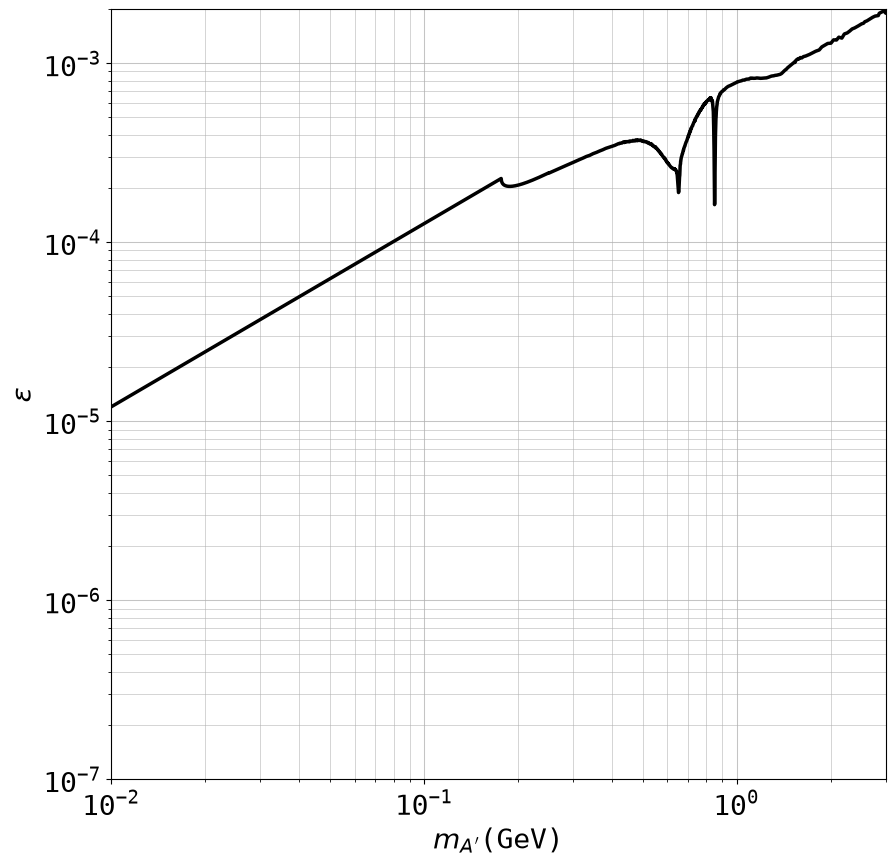

In [27]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Lock the square shape
#ax.set_aspect('equal', adjustable='datalim')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data


#plt.plot(ma, eps_approx_0, color = 'blue', linewidth = 2.5, label = r"$\varepsilon_{relic}$ low effort 1")
plt.plot(ma, eps_approx_1, color = 'black', linewidth = 2.5, label = r"$\epsilon_{relic}$ low effort 2")

## Color palets:

dataset_colors = ['#9671bd', '#7e7e7e', '#77b5b6']
dataset_line_colors = ['#6a408d', '#4e4e4e', '#378d94']

# And the colour for the lines (regressions):
regression_color = '#8a8a8a' # <-- neutral grey
# regression_color = '#7f9fa1' # <-- greyish seafoam


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0]  # change the order of legend elements


'''ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)'''

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_0.pdf", bbox_inches='tight')
plt.show()

### Using the Boltzmann equation:

The complete and more accurate way of solving for the relic abundance comes from solving the Boltzmann equation for out-of-equilibrium particle numbers. Through some standard procedures I will omit, the differential equation can be written in term of the adimensional variable $Y_\chi$, defined as (note some conventions differ on the normalization. We are taking Kolb and Turner's normalization):

$$
Y_{\chi} = \frac{n_\chi}{s},
$$

where $s$ is the entropy density, which can be written as a function of $x$ (or temperature):

$$
s = \frac{2 \pi^2}{45} g_{*s}\left( \frac{m_\chi}{x} \right) \left( \frac{m_\chi}{x} \right)^3,
$$

and $g_{*s}$ are the relativistic degrees of freedom in entropy. The intermediate behaviour of $g_{*s}$ is relatively complicated, and can change abruptly close to the QCD phase transition (confinement into hadrons). For that reason, we use tabulated values interpolated into a functional form: 

In [28]:
### Effective dof from data/effective_dof.csv: g*_e(T) in the energy density
### and g*_s(T) in the entropy density.

# The QCD transition temperature is not settled, so the table lists the
# 150-214 MeV window once per candidate, tagged in the last column by which
# choice(s) the row belongs to ('All' outside that window). Pick one, or
# g*_e is double valued at seven temperatures.
qcd_transition = "170"          # "214", "170" or "150" MeV

dof_table = np.genfromtxt("data/effective_dof.csv", delimiter=',', names=True,
                          dtype=None, encoding='utf-8')

keep_dof = np.array([m == "All" or qcd_transition in m
                     for m in dof_table["transition_temperature_model"]])

T_dof = dof_table["kBT_eV"][keep_dof]*1e-9        # eV -> GeV
gstar_e = dof_table["g_star_e"][keep_dof]
gstar_s = dof_table["g_star_s"][keep_dof]

# Sort on (T, g*_e), not T alone: the transition is a genuine discontinuity,
# tabulated as a '-' and a '+' row at one temperature. g*_e grows with T, so
# breaking the tie on g*_e puts the lower branch first; sorting on T alone
# leaves those two in arbitrary order and can invert the jump. g*_s steps the
# same way across the transition, so this single ordering serves both columns
# and keeps them consistent row by row.
order = np.lexsort((gstar_e, T_dof))
T_dof, gstar_e, gstar_s = T_dof[order], gstar_e[order], gstar_s[order]

# Interpolate against log T: the table is log spaced over nine decades, so
# interpolating against T itself would collapse everything below a GeV.
logT_dof = np.log(T_dof)

# interp1d needs a strictly increasing x, so push each tie up by one float
# step. The jump survives as a near-vertical segment instead of a 0/0.
for i in range(1, len(logT_dof)):
    if logT_dof[i] <= logT_dof[i-1]:
        logT_dof[i] = np.nextafter(logT_dof[i-1], np.inf)

gstar_e_interp = interpolate.interp1d(logT_dof, gstar_e, bounds_error=False,
                                      fill_value=(gstar_e[0], gstar_e[-1]))

gstar_s_interp = interpolate.interp1d(logT_dof, gstar_s, bounds_error=False,
                                      fill_value=(gstar_s[0], gstar_s[-1]))



def gstarfun(T):
    """g*_e at temperature T in GeV, interpolated from the tabulated values.

    Held flat off the ends of the table (10 keV - 10 TeV), where g*_e has
    already plateaued at 3.36 and 106.75 respectively.
    """
    return gstar_e_interp(np.log(np.asarray(T, dtype=float)))


def gstarsfun(T):
    """g*_s at temperature T in GeV, interpolated from the tabulated values.

    Built exactly like gstarfun, off the entropy column. Held flat off the
    ends of the table, where g*_s has plateaued at 3.91 and 106.75. The low
    end sits above g*_e (3.36) because once the neutrinos decouple they stay
    hotter than the photons, and entropy and energy weight that differently.
    """
    return gstar_s_interp(np.log(np.asarray(T, dtype=float)))


The Boltmann equation in terms of $Y_\chi$ are known as the Riccati equations:
$$
\frac{dY_\chi}{dx} = -\frac{x \left\langle \sigma v \right\rangle s }{H(m_\chi)} \left(Y_\chi^2 - Y_{\text{eq}}^2 \right).
$$

If we assume radiation domination at the relevant temperatures, then the Hubble parameter might be written as:
$$
H(T) = \sqrt{\frac{\pi^2}{90}g_{*}(T)}\frac{T^2}{M_{\text{Pl}}},
$$
where $g_*$ is now the relativistic degrees of freedom in the energy density.

We also have that $Y_{\text{eq}}$ can be written in the limit of $x \gg 3$ as:
$$
Y_{\text{eq}} = \frac{45}{2 \pi^2} \frac{g}{g_{*s}(m_\chi/x)} \left( \frac{x}{2 \pi} \right)^{3/2} e^{-x}.
$$

Using these approximations we can integrate the diferential equation to obtain the $Y_\infty$:


In [29]:
# Defining the Riccati equation

H0 = 1.438e-42 # in GeV
T0 = 2.35e-13 # in GeV

def H(T): # Assuming radiation domination
    return np.sqrt(np.pi**2/90 * gstarfun(T))*T**2/Mpl

def s(mchi, x):
    return 2*np.pi**2/45 * gstarsfun(mchi/x)*mchi**3/x**3

def Lambda(vare, ma, alpha, alphaD, mchi, x):
    return sigmavrel(vare, ma, alpha, alphaD, mchi, x)*mchi**3/H(mchi)

def Yeq(x, g, mchi):
    return 45/(2*np.pi**2)* g/gstarsfun(mchi/x) * (x/(2*np.pi))**(3/2) * np.exp(-x)

def dYdx(x, Y, g, vare, ma, alpha, alphaD, mchi):
    return -x*sigmavrel(vare, ma, alpha, alphaD, mchi, x)*s(mchi, x)/(H(mchi)) * (Y**2 - Yeq(x,g, mchi)**2)

xi = 10
xf = 1000

dYdxsolver = lambda x,Y: dYdx(x, Y, g = 2, vare = 1e-3, ma = 1e-1, alpha = 1/137, alphaD = 0.1, mchi = 0.6*1e-1)

xarr = np.logspace(np.log10(xi), np.log10(xf), 10000)
sol = solve_ivp(dYdxsolver, (xarr[0], xarr[-1]), [Yeq(xi,2, mchi=0.6*1e-1)],
                method="Radau", first_step=1e-10,
                t_eval=xarr, rtol=1e-8, atol=1e-12)


In [30]:
gstarsT0 = gstarsfun(T0)

def omega(mchi, Yinf):
    return mchi*Yinf*(2*np.pi**2/45)*gstarsT0*T0**3/(3*Mpl**2*H0**2) 

Finally, to translate $Y_\infty$ into the observed relic abundance of dark matter today, we have that for isentropic expansion (constant entropy per comoving volume) the number density of the species is simply:
$$
n_{\chi,0} = s_0 Y_\infty.
$$
Multiplying by the mass and dividing by the critical density, we obtain that the relic abundance can be simply written as:
$$
\Omega_{\chi} = \frac{2 \pi^2}{45} \frac{m_\chi}{3 H_0^2 M_{\text{pl}}^2} T_0^2 g_{*s}(T_0) Y_\infty.
$$

To reproduce the correct relic abundance, we must scan over the different parameters available for the model $\alpha_D$, $m_\chi$, $m_{A'}$ and $\epsilon$, which are encoded inside the annihilation cross section.

In [31]:
### Scan over (ma, vare) for the epsilon that reproduces the observed Omega.

# The model parameters are alphaD, ma, mchi and vare. Only ma and vare are
# scanned: alphaD is held fixed, and mchi is tied to ma by mchi_over_ma,
# since the relic line is drawn at a fixed mass ratio. Omega ~ 1/(alphaD *
# vare^2), so alphaD shifts the answer as hard as vare does -- at alphaD = 1
# the crossing leaves the vare window over most of the mass range, at 0.1 it
# sits inside it.

def omega_of(ma, vare, alphaD, mchi_over_ma=0.6,
             xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega at one (ma, vare) point, by integrating the Boltzmann eq.

    xi = 10 is safely inside equilibrium (freeze-out is near x ~ 20-25) and
    xfin = 1e3 leaves Y converged to a few times 1e-4; both were chosen by
    measuring, and the cost is dominated by the freeze-out transition rather
    than by the tail.
    """
    mchi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdx(x, Y, 2, vare, ma, alpha, alphaD, mchi)
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, 2, mchi)],
                    method="Radau", rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mchi, sol.y[0][-1])

def solve_window(omfun, ma, v_lo, v_hi, target, tol=0.01, itmax=30):
    """Find the crossing Omega(vare) = target inside [v_lo, v_hi].

    omfun(ma, vare) supplies Omega, so the caller controls alphaD, the mass
    ratio and the solver settings, and can count the calls.

    Omega falls monotonically with vare, so the two ends of the window
    either bracket the target or nothing inside it does. Take the bottom and
    the top first: Omega(v_lo) is the most DM the window can give and
    Omega(v_hi) the least, so those same two values also say which side of
    the window the crossing lies on.

    Then, instead of splitting the bracket down the middle, probe where the
    straight line through its two ends crosses the target. log Omega is very
    nearly linear in log vare (slope about -1.8), so that probe lands almost
    on the root: about four solves in total, against the nine or so halvings
    a factor-200 window would otherwise need.

    Returns (eps, side), side being 'inside', 'below', 'above', or None if
    the solver failed.
    """
    om_lo = omfun(ma, v_lo)
    if np.isfinite(om_lo) and om_lo < target:
        return np.nan, "below"       # needs a smaller vare than the window holds
    om_hi = omfun(ma, v_hi)
    if np.isfinite(om_hi) and om_hi > target:
        return np.nan, "above"       # needs a larger vare than the window holds
    if not (np.isfinite(om_lo) and np.isfinite(om_hi)):
        return np.nan, None

    lo, hi = np.log(v_lo), np.log(v_hi)
    f_lo, f_hi = np.log(om_lo/target), np.log(om_hi/target)   # f_lo > 0 > f_hi
    held = 0

    for _ in range(itmax):
        # Where the chord through (lo, f_lo) and (hi, f_hi) hits zero:
        probe = (lo*f_hi - hi*f_lo)/(f_hi - f_lo)
        om_p = omfun(ma, float(np.exp(probe)))
        if not np.isfinite(om_p) or om_p <= 0:
            return np.nan, None
        f_p = np.log(om_p/target)
        if abs(f_p) < tol:
            return float(np.exp(probe)), "inside"

        if f_p > 0:                  # still too much DM, so vare must rise
            # Illinois tweak: if the same end keeps being replaced the other
            # one goes stale and the probe crawls, so halve its weight.
            if held > 0:
                f_hi *= 0.5
            lo, f_lo, held = probe, f_p, 1
        else:
            if held < 0:
                f_lo *= 0.5
            hi, f_hi, held = probe, f_p, -1

    # Tolerance never met: interpolate across what is left of the bracket,
    # which costs nothing since both ends are already known.
    return float(np.exp((lo*f_hi - hi*f_lo)/(f_hi - f_lo))), "inside"

# log Omega vs log vare is close to a straight line of slope -2, but not
# exactly, because the freeze-out x drifts with the coupling. Measured ~-1.8.
LOGSLOPE = -1.8

def predict_eps(i, ma_grid, eps_found):
    """Extrapolate eps for mass i from the last two solved masses.

    Just re-centring on the previous eps systematically undershoots, since
    eps(ma) is rising; continuing the local power law lands much closer and
    saves an iteration or two per mass.

    Returned UNCLIPPED on purpose: an out-of-window prediction is the signal
    that the relic line may have left the scan range.
    """
    solved = [(m, e) for m, e in zip(ma_grid[:i], eps_found[:i]) if np.isfinite(e)]
    if not solved:
        return None
    if len(solved) == 1:
        return solved[-1][1]
    (m1, e1), (m2, e2) = solved[-2], solved[-1]
    slope = np.log(e2/e1)/np.log(m2/m1)
    return float(e2*(ma_grid[i]/m2)**slope)

def refine_eps(omfun, ma, guess, v_lo, v_hi, target, tol=0.01, itmax=6):
    """Walk from a nearby guess to the crossing Omega = target.

    One ODE solve per step, and LOGSLOPE turns each into a Newton step, so
    this lands within tol of the target in a handful of solves. Returns nan
    if it walks outside [v_lo, v_hi].
    """
    le = np.log(guess)
    for _ in range(itmax):
        om = omfun(ma, float(np.exp(le)))
        if not np.isfinite(om) or om <= 0:
            return np.nan
        r = np.log(om/target)
        if abs(r) < tol:
            return float(np.exp(le))
        le += r/(-LOGSLOPE)
        if not (np.log(v_lo) <= le <= np.log(v_hi)):
            return np.nan
    return float(np.exp(le))

def scan_relic_line(ma_grid, vare_lo, vare_hi, alphaD, mchi_over_ma=0.6,
                    target=None, tol=0.01, solver=None, verbose=True,
                    omega_fun=None):
    """eps(ma) reproducing the relic abundance, at fixed alphaD and mass ratio.

    Scans only ma and vare: ma over ma_grid, vare bracketed by
    [vare_lo, vare_hi]. alphaD is fixed, and mchi = mchi_over_ma*ma.

    Every mass after the first starts from the ones already solved and only
    looks nearby. Anything that fails there -- the first mass, an
    extrapolation that has left the window, a Newton walk that wandered off
    -- falls back to searching the whole window, which also reports which
    side of it the crossing lies on.

    eps(ma) rises monotonically, so the line can leave the window in two
    ways and they need opposite responses:
      - below the window, at the light end, before it has ever been found:
        keep going, the line is climbing and may still enter the range;
      - above the window, at the heavy end: nothing further can be solved,
        so stop rather than search on every remaining mass.

    solver is an optional dict of keywords forwarded to omega_fun (xi, xfin,
    rtol, atol). omega_fun defaults to omega_of, the scalar model; pass
    omega_of_dirac for the Dirac fermion. Everything else here -- the
    bracketing, the warm start, the early stop -- only sees Omega(ma, vare)
    and so is shared between the two.

    Returns (eps, info) with eps a masked-by-nan array over ma_grid, and info
    carrying the solve count and why the scan stopped.
    """
    if omega_fun is None:
        omega_fun = omega_of
    if target is None:
        target = OmegaDM
    ma_grid = np.asarray(ma_grid, dtype=float)
    stats = {"nsolve": 0}

    def omfun(ma, vare):
        stats["nsolve"] += 1
        return omega_fun(ma, vare, alphaD, mchi_over_ma, **(solver or {}))

    eps = np.full(ma_grid.shape, np.nan)
    stop_note = None
    i_stop = len(ma_grid)

    for i, ma_i in enumerate(ma_grid):
        guess = predict_eps(i, ma_grid, eps)

        found = np.nan
        if guess is not None and vare_lo <= guess <= vare_hi:
            found = refine_eps(omfun, ma_i, guess, vare_lo, vare_hi, target, tol)

        if not np.isfinite(found):
            found, side = solve_window(omfun, ma_i, vare_lo, vare_hi, target, tol)
            if side == "above":
                stop_note = (f"crossing lies above the window at ma = {ma_i:.4g} GeV"
                             + (f" (extrapolated eps = {guess:.3e} > {vare_hi:g})"
                                if guess is not None else ""))
                i_stop = i
                break
            # 'below' or None: the line is not in range here, carry on

        eps[i] = found

    nfound = int(np.isfinite(eps).sum())
    info = {"nsolve": stats["nsolve"], "nfound": nfound,
            "stop_note": stop_note, "i_stop": i_stop,
            "alphaD": alphaD, "mchi_over_ma": mchi_over_ma, "target": target,
            "model": omega_fun.__name__}

    if verbose:
        print(f"alphaD = {alphaD:g}, mchi/ma = {mchi_over_ma:g},"
              f" Omega target = {target:g}")
        print(f"solved {nfound} of {len(ma_grid)} masses in {stats['nsolve']}"
              f" ODE integrations ({stats['nsolve']/max(nfound, 1):.1f} per solved mass)")
        if stop_note is not None:
            print(f"stopped early at index {i_stop}: {stop_note}")
            print(f"  {len(ma_grid) - i_stop} masses left unscanned"
                  f" (ma >= {ma_grid[i_stop]:.4g} GeV)")
        if nfound:
            got = ma_grid[np.isfinite(eps)]
            print(f"  solved range ma = {got[0]:.4g} to {got[-1]:.4g} GeV")
        else:
            print(f"no vare in [{vare_lo:g}, {vare_hi:g}] reaches {target};"
                  f" Omega(ma={ma_grid[0]:.3g}, vare={vare_lo:g})"
                  f" = {omfun(ma_grid[0], vare_lo):.3e}")
    return eps, info

We can run multiple scans for different $\alpha_D$ and $m_\chi/m_{A'}$:

In [32]:
### Running the scan:

ma_scan1 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo1, vare_hi1 = 1e-5, 2e-3

eps_relic1, scan_info1 = scan_relic_line(ma_scan1, vare_lo1, vare_hi1,
                                       alphaD=0.1, mchi_over_ma=0.6)


alphaD = 0.1, mchi/ma = 0.6, Omega target = 0.265
solved 90 of 100 masses in 155 ODE integrations (1.7 per solved mass)
stopped early at index 90: crossing lies above the window at ma = 1.786 GeV (extrapolated eps = 1.974e-03 > 0.002)
  10 masses left unscanned (ma >= 1.786 GeV)
  solved range ma = 0.01 to 1.686 GeV


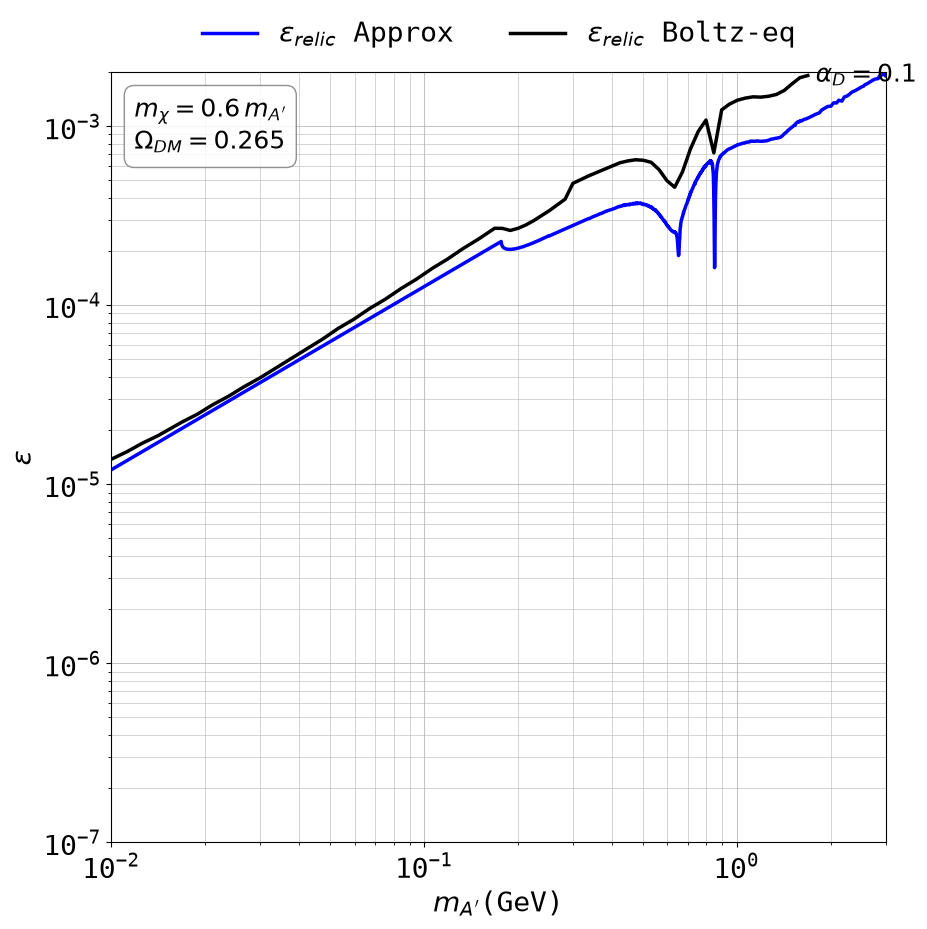

In [33]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data


plt.plot(ma, eps_approx_1, color = 'blue', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Approx")


plt.plot(ma_scan1, eps_relic1, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

## The parameters that were held fixed rather than scanned over. Both the
## shared box and the per-curve labels are read back out of the scan info
## dicts, so the annotation cannot drift away from what was actually run.

relic_curves = [(ma_scan1, eps_relic1, scan_info1)]

fixed_ratio = {info_i["mchi_over_ma"] for _, _, info_i in relic_curves}
if len(fixed_ratio) > 1:
    print("warning: the box states a single mchi/ma, but the curves use",
          sorted(fixed_ratio))

ax.text(0.03, 0.97,
        "\n".join([r"$m_\chi = %g\, m_{A'}$" % scan_info1["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % scan_info1["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## alphaD differs between the Boltzmann curves here, so it is tagged on each
## one at its end rather than collected in the box, where it could not say
## which curve is which.
for ma_i, eps_i, info_i in relic_curves:
    ok_i = np.isfinite(eps_i)
    if ok_i.any():
        ax.text(ma_i[ok_i][-1]*1.06, eps_i[ok_i][-1],
                r"$\alpha_D = %g$" % info_i["alphaD"],
                va = 'center', ha = 'left', fontsize = 18)


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 1]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)


# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_scan_0.pdf", bbox_inches='tight')
plt.show()

In [34]:
ma_scan2 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo2, vare_hi2 = 1e-7, 2e-3

eps_relic2, scan_info2 = scan_relic_line(ma_scan2, vare_lo2, vare_hi2,
                                       alphaD=0.95, mchi_over_ma=0.6)

alphaD = 0.95, mchi/ma = 0.6, Omega target = 0.265
solved 100 of 100 masses in 171 ODE integrations (1.7 per solved mass)
  solved range ma = 0.01 to 3 GeV


In [35]:
ma_scan3 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo3, vare_hi3 = 1e-5, 2e-3

eps_relic3, scan_info3 = scan_relic_line(ma_scan3, vare_lo3, vare_hi3,
                                       alphaD=0.03, mchi_over_ma=0.6)

alphaD = 0.03, mchi/ma = 0.6, Omega target = 0.265
solved 78 of 100 masses in 117 ODE integrations (1.5 per solved mass)
stopped early at index 78: crossing lies above the window at ma = 0.8947 GeV (extrapolated eps = 8.498e-04 > 0.002)
  22 masses left unscanned (ma >= 0.8947 GeV)
  solved range ma = 0.01 to 0.8446 GeV


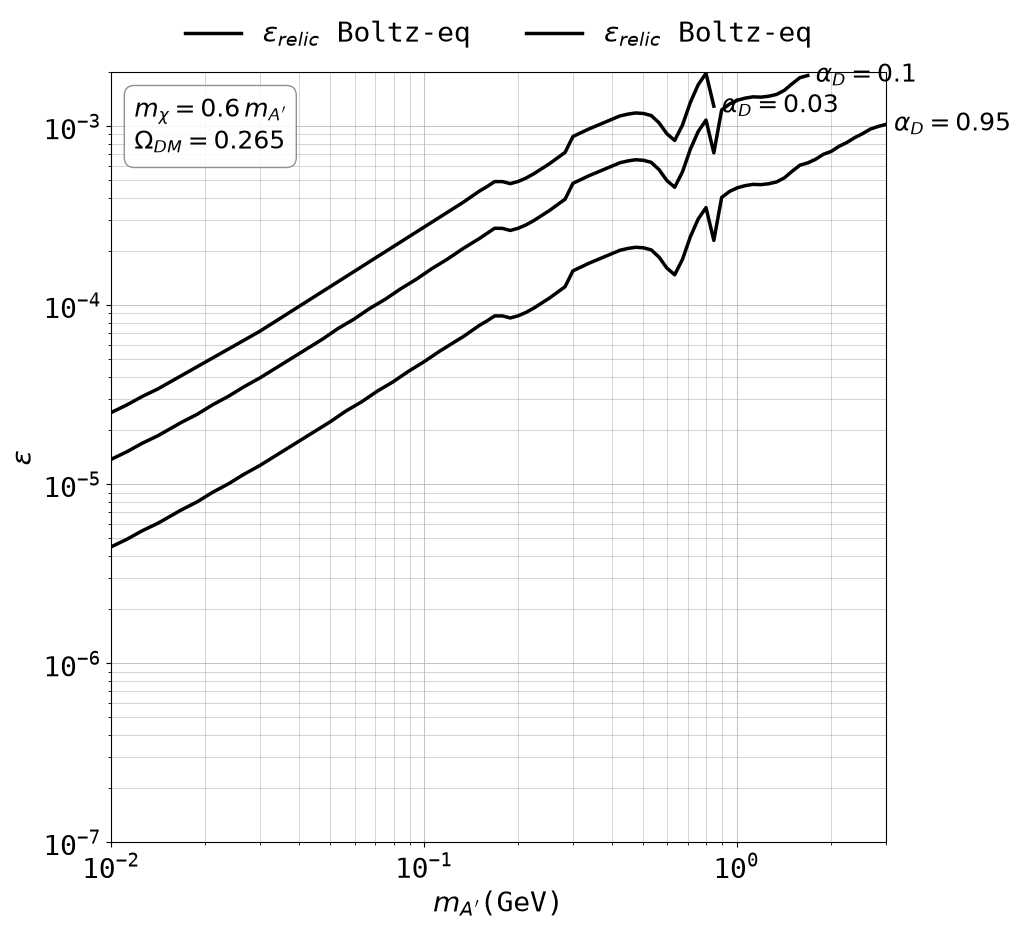

In [36]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

plt.plot(ma_scan1, eps_relic1, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

plt.plot(ma_scan2, eps_relic2, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

plt.plot(ma_scan3, eps_relic3, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Boltz-eq")

## The parameters that were held fixed rather than scanned over. Both the
## shared box and the per-curve labels are read back out of the scan info
## dicts, so the annotation cannot drift away from what was actually run.

relic_curves = [(ma_scan1, eps_relic1, scan_info1),
                (ma_scan2, eps_relic2, scan_info2),
                (ma_scan3, eps_relic3, scan_info3)]

fixed_ratio = {info_i["mchi_over_ma"] for _, _, info_i in relic_curves}
if len(fixed_ratio) > 1:
    print("warning: the box states a single mchi/ma, but the curves use",
          sorted(fixed_ratio))

ax.text(0.03, 0.97,
        "\n".join([r"$m_\chi = %g\, m_{A'}$" % scan_info1["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % scan_info1["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## alphaD differs between the Boltzmann curves here, so it is tagged on each
## one at its end rather than collected in the box, where it could not say
## which curve is which.
for ma_i, eps_i, info_i in relic_curves:
    ok_i = np.isfinite(eps_i)
    if ok_i.any():
        ax.text(ma_i[ok_i][-1]*1.06, eps_i[ok_i][-1],
                r"$\alpha_D = %g$" % info_i["alphaD"],
                va = 'center', ha = 'left', fontsize = 18)


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = [0, 1]  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)


# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_scan_1.pdf", bbox_inches='tight')
plt.show()

We can also scan over mass ratios, remembering $0.5 m_{A'} \leq m_\chi \leq m_{A'}$ 

In [37]:
ma_scan4 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo4, vare_hi4 = 1e-5, 2e-3

eps_relic4, scan_info4 = scan_relic_line(ma_scan4, vare_lo4, vare_hi4,
                                       alphaD=0.1, mchi_over_ma=0.7)

alphaD = 0.1, mchi/ma = 0.7, Omega target = 0.265
solved 76 of 100 masses in 124 ODE integrations (1.6 per solved mass)
stopped early at index 76: crossing lies above the window at ma = 0.7973 GeV (extrapolated eps = 1.937e-03 > 0.002)
  24 masses left unscanned (ma >= 0.7973 GeV)
  solved range ma = 0.01 to 0.7527 GeV


In [38]:
ma_scan5 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo5, vare_hi5 = 1e-5, 2e-3

eps_relic5, scan_info5 = scan_relic_line(ma_scan5, vare_lo5, vare_hi5,
                                       alphaD=0.1, mchi_over_ma=0.8)

alphaD = 0.1, mchi/ma = 0.8, Omega target = 0.265
solved 71 of 100 masses in 115 ODE integrations (1.6 per solved mass)
stopped early at index 71: crossing lies above the window at ma = 0.5978 GeV (extrapolated eps = 2.334e-03 > 0.002)
  29 masses left unscanned (ma >= 0.5978 GeV)
  solved range ma = 0.01 to 0.5643 GeV


In [39]:
ma_scan6 = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo6, vare_hi6 = 1e-5, 2e-3

eps_relic6, scan_info6 = scan_relic_line(ma_scan6, vare_lo6, vare_hi6,
                                       alphaD=0.1, mchi_over_ma=0.9)

alphaD = 0.1, mchi/ma = 0.9, Omega target = 0.265
solved 68 of 100 masses in 111 ODE integrations (1.6 per solved mass)
stopped early at index 68: crossing lies above the window at ma = 0.5029 GeV (extrapolated eps = 2.316e-03 > 0.002)
  32 masses left unscanned (ma >= 0.5029 GeV)
  solved range ma = 0.01 to 0.4747 GeV


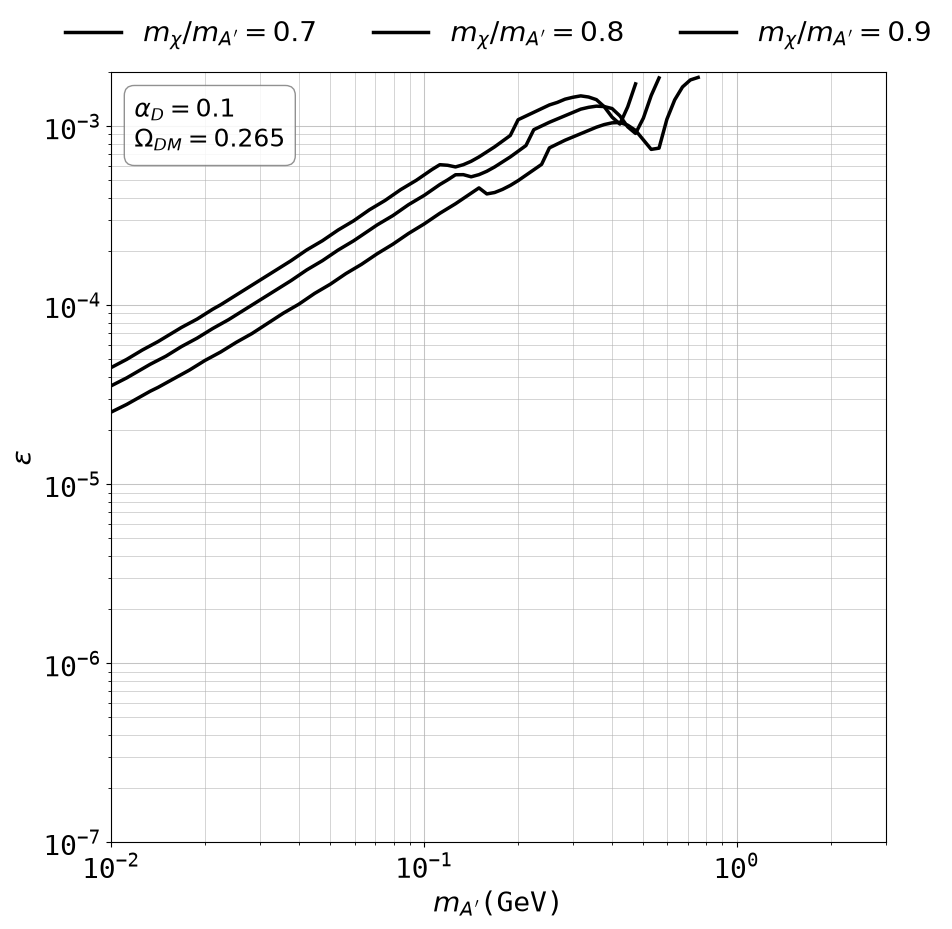

In [40]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data

## On this figure mchi/ma is what varies between the curves, so alphaD is
## the one that goes in the fixed-parameter box. The ratio cannot be tagged
## on the end of each curve the way alphaD is on the other figure: these
## three all finish within a few percent of each other in epsilon, so the
## labels would sit on top of one another. It goes in the legend instead.
relic_curves = [(ma_scan4, eps_relic4, scan_info4),
                (ma_scan5, eps_relic5, scan_info5),
                (ma_scan6, eps_relic6, scan_info6)]

for ma_i, eps_i, info_i in relic_curves:
    plt.plot(ma_i, eps_i, color = 'black', linewidth = 2.5,
             label = r"$m_\chi/m_{A'} = %g$" % info_i["mchi_over_ma"])


## The parameters that were held fixed rather than scanned over, read back
## out of the scan info dicts so the annotation cannot drift away from what
## was actually run.

fixed_alphaD = {info_i["alphaD"] for _, _, info_i in relic_curves}
if len(fixed_alphaD) > 1:
    print("warning: the box states a single alphaD, but the curves use",
          sorted(fixed_alphaD))

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % relic_curves[0][2]["alphaD"],
                   r"$\Omega_{DM} = %g$" % relic_curves[0][2]["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)


# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_scan_2.pdf", bbox_inches='tight')
plt.show()

## Dirac Fermion case:

The situation changes slighly. Now, for a Dirac fermion $\psi$ as the dark matter particle, using the same asumptions the annihilation cross section in the non-relativistic limit goes as:

$$
\left\langle \sigma v_{\text{rel}} \right\rangle_{\text{Dirac}} = 16 \pi \frac{\epsilon^2 \alpha \alpha_D m^2_\psi}{\left( m_{A'}^2 - 4 m_\psi^2  \right)^2}  \sum_f K^\psi_f(x),
$$

where the kinematic factor now contains both s-wave and p-wave contributions, meaning the dependence on $x$ cannot be factored out. The expression for this kinematic factor is:

$$
K^\psi_f(x) = Q_f^2 N_c^f \sqrt{1 - \frac{m_f^2}{m_\psi^2}} \left[ \left( 1 + \frac{1}{2} \frac{m_f^2}{m_\psi^2} \right) + \frac{1}{16} \left( 1 - \frac{m_f^2}{m_\psi^2} \right) \frac{1}{x} \right] \Theta \left( m_\psi - m_f \right),
$$

and the R ratio use does not change:

$$

\sum_f K^\psi_f(x) \sim \sum_l K^\psi_l (x, m_\psi) + R(2 m_\psi) K^\psi_\mu(x, m_\psi).

$$

### Annihilation cross section

Everything outside the kinematic factor is unchanged, so the $R$ ratio read from the PDG table above is reused as it stands. Only $K_f$ is rewritten, with two differences: the mass correction to the s-wave term is $\frac{1}{2} m_f^2/m_\psi^2$ rather than $\frac{1}{6}$, and $x$ now enters the kinematic factor itself instead of factoring out in front of the sum.

In [41]:
### Dirac fermion DM: same structure as the scalar case, but the kinematic
### factor now carries the x dependence, so every K takes x as an argument.

def Kldirac(mpsi, ml, x):
    """Phase-space factor for psi psibar -> l+ l-, zero below threshold.

    Built like Kl: the sqrt and the 1/mpsi**2 are only evaluated where
    mpsi > ml, so closed channels contribute an exact 0 instead of a nan.
    The bracket is the s-wave term (1 + r2/2) plus the p-wave term
    (1 - r2)/(16 x); at freeze-out the second is a ~0.3% correction, so the
    Dirac cross section is s-wave dominated.
    """
    mpsi = np.asarray(mpsi, dtype=float)
    x = np.asarray(x, dtype=float)
    opench = mpsi > ml
    r2 = np.where(opench, ml**2/np.where(opench, mpsi, 1.0)**2, 0.0)
    return np.where(opench,
                    np.sqrt(1 - r2)*((1 + r2/2) + (1 - r2)/(16*x)), 0.0)

def sumKldirac(mpsi, x):
    # Broadcast first so the running total has the shape of whichever of the
    # two is an array: mpsi varies along the mass axis, x along the solver's.
    mpsi, x = np.broadcast_arrays(np.asarray(mpsi, dtype=float),
                                  np.asarray(x, dtype=float))
    total = np.zeros_like(mpsi)
    for ml in mleptons:
        total = total + Kldirac(mpsi, ml, x)
    return total

def Kmudirac(mpsi, x):
    """Muon factor, deliberately WITHOUT a threshold cut.

    Same reasoning as Kmu in the scalar case: this is the mu+mu-
    normalisation of the R ratio, not an open channel of its own, so the
    kinematic condition belongs to R (see RKmudirac).
    """
    mpsi = np.asarray(mpsi, dtype=float)
    r2 = mleptons[1]**2/mpsi**2
    return np.sqrt(1 - r2)*((1 + r2/2) + (1 - r2)/(16*x))

def RKmudirac(mpsi, x):
    """Hadronic contribution R(2*mpsi)*Kmudirac(mpsi, x)."""
    mpsi = np.asarray(mpsi, dtype=float)
    Rval = np.asarray(R(2*mpsi), dtype=float)
    hadopen = Rval != 0.0
    safe = np.where(hadopen, mpsi, np.inf)   # keeps Kmudirac real where R == 0
    return np.where(hadopen, Rval*Kmudirac(safe, x), 0.0)


def sigmavreldirac(vare, ma, alpha, alphaD, mpsi, x):
    """<sigma v_rel> for Dirac DM. Note the missing 1/x out front: unlike the
    scalar case the leading term is s-wave, so the only x dependence left is
    the small p-wave piece inside the K's."""
    return 16*np.pi * (vare**2*alpha*alphaD*mpsi**2)/(ma**2 - 4*mpsi**2)**2 \
           * (sumKldirac(mpsi, x) + RKmudirac(mpsi, x))

### Relic target line calculation

#### Closed form approximations:

The approximations are the same as before. The freeze out temperature is still estimated as

$$
x_f \approx \ln \left( \left\langle \sigma v_{\text{rel}} \right\rangle m_{\text{pl}} m_\psi \right),
$$

and the relic target is still $\left\langle \sigma v_{\text{rel}} \right\rangle_{\text{relic}} \sim 5 \times 10^{-9} \, \text{GeV}^{-2}$, which is the value for a non self-conjugate species and so applies unchanged to a Dirac fermion, exactly as it did to the complex scalar. Solving for $\epsilon$ now means solving:

$$
16 \pi \frac{\epsilon^2 \alpha \alpha_D m^2_\psi}{\left( m_{A'}^2 - 4 m_\psi^2  \right)^2}  \sum_f K^\psi_f(x_f) = 5 \times 10^{-9} \, \text{GeV}^{-2}.
$$

This is still explicit in $\epsilon$: $x_f$ is estimated from the target cross section rather than from $\left\langle \sigma v_{\text{rel}} \right\rangle(\epsilon)$, so the right hand side is a known number and $\epsilon \propto \left( \sum_f K^\psi_f \right)^{-1/2}$ as before.

Two consequences of losing the overall $1/x$ are worth noting. The line sits lower by roughly $\sqrt{x_f} \approx 5$ in $\epsilon$, since s-wave annihilation reaches the target cross section with a much smaller coupling than the velocity suppressed p-wave one. And the answer is now almost independent of how $x_f$ is estimated: $x_f$ only survives inside the p-wave term, so the two choices below agree to better than $0.1 \%$, where in the scalar case they differ by around $10 \%$.

In [42]:
### Rough calculation for the relic abundance, Dirac case.

sigmav_relic = 5e-9   # GeV^-2, the thermal target used for the scalar case too

# Epsilon for the relic line taking xf as a constant and as a function of the
# thermal production cross section. Both reuse mpl, the non reduced Planck
# mass, defined with the scalar case above.

def eps_approx0_dirac(ma, alpha, alphaD, mpsi):
    xf = 20
    return np.sqrt(sigmav_relic/(sigmavreldirac(1, ma, alpha, alphaD, mpsi, xf)))

def eps_approx1_dirac(ma, alpha, alphaD, mpsi):
    xf = np.log(sigmav_relic*mpl*mpsi)
    return np.sqrt(sigmav_relic/(sigmavreldirac(1, ma, alpha, alphaD, mpsi, xf)))

In [43]:
# Same testing parameters and same ma grid as the scalar case, so the two
# closed form lines can be compared point by point.

mpsi = 0.6*ma

eps_approx_0_dirac = eps_approx0_dirac(ma, alpha, alphaD, mpsi)

eps_approx_1_dirac = eps_approx1_dirac(ma, alpha, alphaD, mpsi)

# The two xf choices barely differ here, and the Dirac line sits about
# sqrt(xf) below the scalar one. Both are checked rather than asserted, since
# they are the two things the missing 1/x is supposed to do.
inrange = (ma >= 1e-2) & (ma <= 3.0)
print("max |eps_approx0/eps_approx1 - 1| over the plotted range:"
      f" {np.max(np.abs(eps_approx_0_dirac[inrange]/eps_approx_1_dirac[inrange] - 1)):.2e}")
print("eps_scalar/eps_dirac ranges over"
      f" {np.min(eps_approx_1[inrange]/eps_approx_1_dirac[inrange]):.2f} to"
      f" {np.max(eps_approx_1[inrange]/eps_approx_1_dirac[inrange]):.2f},"
      f" against sqrt(xf) = {np.sqrt(np.log(sigmav_relic*mpl*0.6*1.0)):.2f} at ma = 1 GeV")

max |eps_approx0/eps_approx1 - 1| over the plotted range: 3.30e-04
eps_scalar/eps_dirac ranges over 4.45 to 5.08, against sqrt(xf) = 4.93 at ma = 1 GeV


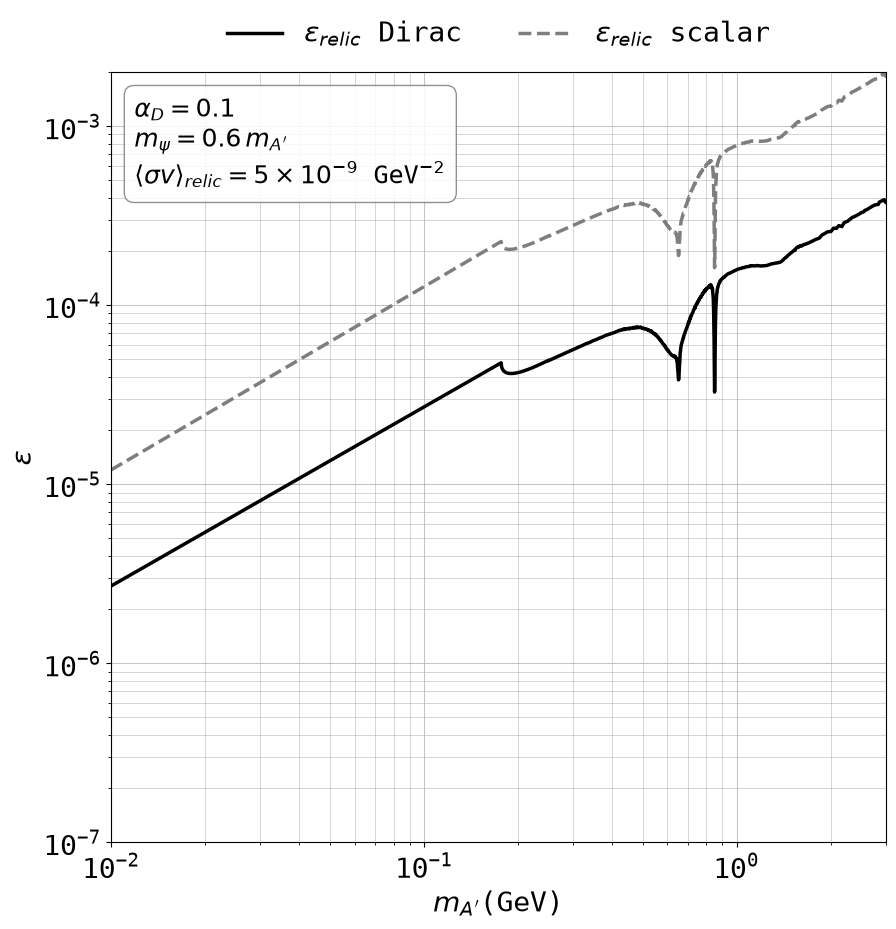

In [44]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\varepsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data


#plt.plot(ma, eps_approx_0_dirac, color = 'blue', linewidth = 2.5, label = r"$\varepsilon_{relic}$ low effort 1")
plt.plot(ma, eps_approx_1_dirac, color = 'black', linewidth = 2.5, label = r"$\varepsilon_{relic}$ Dirac")

## The scalar line for comparison. The gap between the two is the sqrt(xf)
## of the p-wave suppression, not a change of parameters: alphaD, the mass
## ratio and the relic cross section are identical on both curves.
plt.plot(ma, eps_approx_1, color = '#7e7e7e', linewidth = 2.5,
         linestyle = '--', label = r"$\varepsilon_{relic}$ scalar")

## Split the target into mantissa and exponent rather than printing it with
## %g, which would render 5e-09 verbatim in the middle of the maths.
sv_mant, sv_exp = f"{sigmav_relic:.0e}".split("e")

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % alphaD,
                   r"$m_\psi = 0.6\, m_{A'}$",
                   r"$\langle \sigma v \rangle_{relic} = %s \times 10^{%d}$ GeV$^{-2}$"
                   % (sv_mant, int(sv_exp))]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))

## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)

# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_dirac_0.pdf", bbox_inches='tight')
plt.show()

### Solving Boltzmann's equation

Nothing changes from the previous case, just annihilation cross section:

In [45]:
### Boltzmann equation for the Dirac case.

# H, s and Yeq are unchanged: they describe the bath and the equilibrium
# abundance, neither of which knows the spin of the dark matter. Only the
# cross section and the internal dof differ, so this is dYdx with
# sigmavreldirac in place of sigmavrel.

def dYdxdirac(x, Y, g, vare, ma, alpha, alphaD, mpsi):
    return -x*sigmavreldirac(vare, ma, alpha, alphaD, mpsi, x)*s(mpsi, x)/(H(mpsi)) \
           * (Y**2 - Yeq(x, g, mpsi)**2)

# 2 spin states x (psi, psibar). The complex scalar is counted the same way
# and uses 2, so the two models are normalised alike and the lines compare
# directly.
GDIRAC = 4

def omega_of_dirac(ma, vare, alphaD, mchi_over_ma=0.6,
                   xi=1e1, xfin=1e3, rtol=1e-6, atol=1e-25):
    """Relic Omega at one (ma, vare) point for Dirac DM.

    Deliberately the same signature as omega_of, so scan_relic_line takes
    either one through its omega_fun argument.
    """
    mpsi = mchi_over_ma*ma
    rhs = lambda x, Y: dYdxdirac(x, Y, GDIRAC, vare, ma, alpha, alphaD, mpsi)
    sol = solve_ivp(rhs, (xi, xfin), [Yeq(xi, GDIRAC, mpsi)],
                    method="Radau", rtol=rtol, atol=atol)
    if not sol.success:
        return np.nan
    return omega(mpsi, sol.y[0][-1])

# The Newton step in refine_eps uses LOGSLOPE, which was measured on the
# scalar model. Check that it still describes this one rather than assuming.
_v1, _v2 = 1e-5, 1e-4
print("d log Omega / d log vare, Dirac, at alphaD = 0.1:")
for _ma in [0.01, 0.1, 1.0, 3.0]:
    _o1, _o2 = omega_of_dirac(_ma, _v1, 0.1), omega_of_dirac(_ma, _v2, 0.1)
    print(f"  ma = {_ma:5g} GeV: {np.log(_o2/_o1)/np.log(_v2/_v1):6.2f}"
          f"   (LOGSLOPE = {LOGSLOPE})")


d log Omega / d log vare, Dirac, at alphaD = 0.1:
  ma =  0.01 GeV:  -1.86   (LOGSLOPE = -1.8)
  ma =   0.1 GeV:  -1.88   (LOGSLOPE = -1.8)
  ma =     1 GeV:  -1.85   (LOGSLOPE = -1.8)
  ma =     3 GeV:  -1.82   (LOGSLOPE = -1.8)


In [46]:
### Running the scan, same alphaD and mass ratio as the closed form above.

# The window starts a decade lower than the scalar scans: s-wave annihilation
# reaches the relic cross section at a smaller coupling, so the whole line
# sits around 5x below the scalar one.

ma_scan_dirac = np.logspace(np.log10(1e-2), np.log10(3.0), 100)
vare_lo_dirac, vare_hi_dirac = 1e-6, 2e-3

eps_relic_dirac, scan_info_dirac = scan_relic_line(
    ma_scan_dirac, vare_lo_dirac, vare_hi_dirac,
    alphaD=0.1, mchi_over_ma=0.6, omega_fun=omega_of_dirac)


alphaD = 0.1, mchi/ma = 0.6, Omega target = 0.265
solved 100 of 100 masses in 170 ODE integrations (1.7 per solved mass)
  solved range ma = 0.01 to 3 GeV


In [47]:
### Closed form against Boltzmann, on the masses the scan actually solved.

ok_dirac = np.isfinite(eps_relic_dirac)
eps_closed_on_scan = eps_approx1_dirac(ma_scan_dirac[ok_dirac], alpha, 0.1,
                                       0.6*ma_scan_dirac[ok_dirac])
ratio_dirac = eps_closed_on_scan/eps_relic_dirac[ok_dirac]

print(f"closed form / Boltzmann over {ok_dirac.sum()} solved masses:"
      f" {ratio_dirac.min():.3f} to {ratio_dirac.max():.3f}"
      f" (median {np.median(ratio_dirac):.3f})")

# Confirm the returned epsilons really do reproduce the target, since the
# scan stops on a tolerance in log Omega rather than in eps.
_check = np.linspace(0, ok_dirac.sum() - 1, 5, dtype=int)
print("spot check, Omega at the returned eps:")
for j in _check:
    _ma = ma_scan_dirac[ok_dirac][j]
    _ep = eps_relic_dirac[ok_dirac][j]
    print(f"  ma = {_ma:7.4f} GeV, eps = {_ep:.4e} ->"
          f" Omega = {omega_of_dirac(_ma, _ep, 0.1):.4f}"
          f"  (target {scan_info_dirac['target']})")


closed form / Boltzmann over 100 solved masses: 0.690 to 1.095 (median 0.979)
spot check, Omega at the returned eps:
  ma =  0.0100 GeV, eps = 2.7443e-06 -> Omega = 0.2653  (target 0.265)
  ma =  0.0399 GeV, eps = 9.9354e-06 -> Omega = 0.2651  (target 0.265)
  ma =  0.1683 GeV, eps = 4.6373e-05 -> Omega = 0.2636  (target 0.265)
  ma =  0.7105 GeV, eps = 1.2237e-04 -> Omega = 0.2627  (target 0.265)
  ma =  3.0000 GeV, eps = 5.2066e-04 -> Omega = 0.2652  (target 0.265)


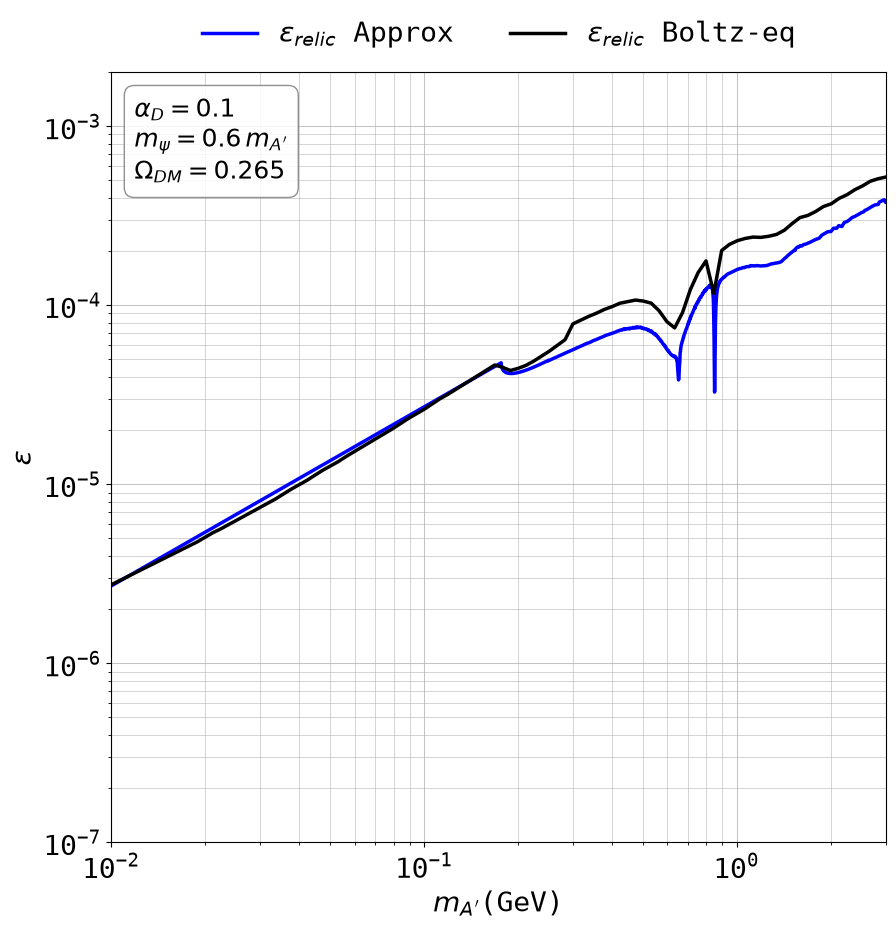

In [48]:
## Creating a plot:

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlabel(r"$m_{A'}$(GeV)")
ax.set_ylabel(r"$\epsilon$")

## Log Axis
ax.set_xscale('log')
ax.set_yscale('log')

## Major grid:
ax.grid(True, which='major', linestyle='-', linewidth=0.75, alpha=0.75)

## Minor ticks and grid:
ax.minorticks_on()
ax.grid(True, which='minor', linestyle='-', linewidth=0.5, alpha=0.75)

ax.set_axisbelow(True) # Ensure grid is below data


plt.plot(ma, eps_approx_1_dirac, color = 'blue', linewidth = 2.5,
         label = r"$\varepsilon_{relic}$ Approx")

plt.plot(ma_scan_dirac, eps_relic_dirac, color = 'black', linewidth = 2.5,
         label = r"$\varepsilon_{relic}$ Boltz-eq")

## The parameters that were held fixed rather than scanned over, read back
## out of the scan info dict so the annotation cannot drift away from what
## was actually run.

ax.text(0.03, 0.97,
        "\n".join([r"$\alpha_D = %g$" % scan_info_dirac["alphaD"],
                   r"$m_\psi = %g\, m_{A'}$" % scan_info_dirac["mchi_over_ma"],
                   r"$\Omega_{DM} = %g$" % scan_info_dirac["target"]]),
        transform = ax.transAxes, va = 'top', ha = 'left', fontsize = 18,
        bbox = dict(boxstyle = 'round,pad=0.4', facecolor = 'white',
                    edgecolor = '#7e7e7e', alpha = 0.85))


## Setting a costumised legend:
handles, labels = ax.get_legend_handles_labels() # get all legend items
desired_order = range(len(handles))  # change the order of legend elements

ax.legend(
    [handles[i] for i in desired_order],
    [labels[i] for i in desired_order],
    loc = 'upper center',
    bbox_to_anchor = (0.5, 1.10),  # center top, above axes
    ncol = 4,                      # spread horizontally
    frameon = False                # removes legend border
)


# Define how much to zoom out from the data plotting range (cm):
x_min = 1e-2
x_max = 3
x_range = x_max - x_min

y_min = 1e-7
y_max = 2e-3
y_range = y_max - y_min

# Set the new plotting limits explicitly
ax.set_xbound(x_min, x_max)
ax.set_ybound(y_min, y_max)

# Save and show the figure:
plt.savefig("figures/relic_abundance_dirac_scan_0.pdf", bbox_inches='tight')
plt.show()
